In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.api import qqplot
from warnings import simplefilter

In [49]:
plt.style.use('Solarize_Light2')
simplefilter('ignore')

In [50]:
print(sm.datasets.sunspots.NOTE)

::

    Number of Observations - 309 (Annual 1700 - 2008)
    Number of Variables - 1
    Variable name definitions::

        SUNACTIVITY - Number of sunspots for each year

    The data file contains a 'YEAR' variable that is not returned by load.



In [51]:
dta=sm.datasets.sunspots.load_pandas().data

In [52]:
dta

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0
...,...,...
304,2004.0,40.4
305,2005.0,29.8
306,2006.0,15.2
307,2007.0,7.5


In [53]:
dta.index=pd.Index(sm.tsa.datetools.dates_from_range("1700", "2008"))
dta.index.freq=dta.index.inferred_freq
del dta['YEAR']

In [54]:
dta

,SUNACTIVITY
1700-12-31,5.0
1701-12-31,11.0
1702-12-31,16.0
1703-12-31,23.0
1704-12-31,36.0
...,...
2004-12-31,40.4
2005-12-31,29.8
2006-12-31,15.2
2007-12-31,7.5


<Axes: >

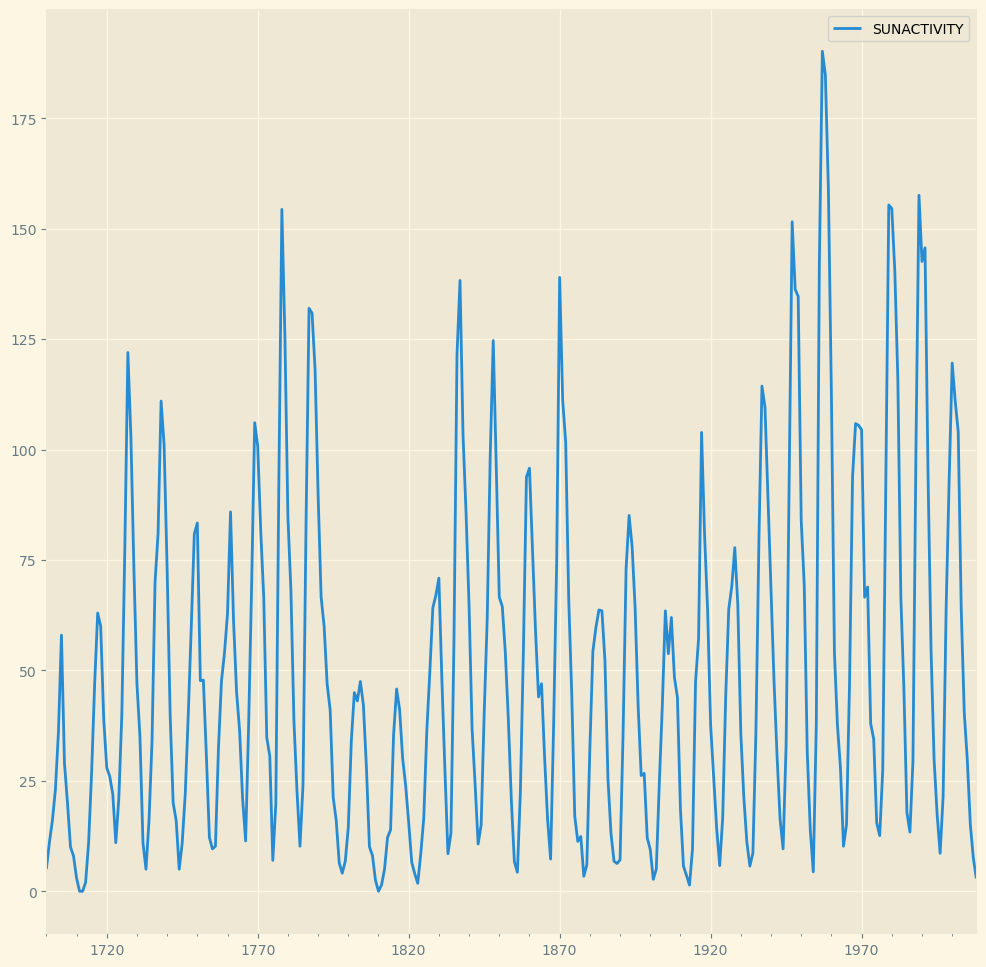

In [55]:
dta.plot(figsize=(12,12))

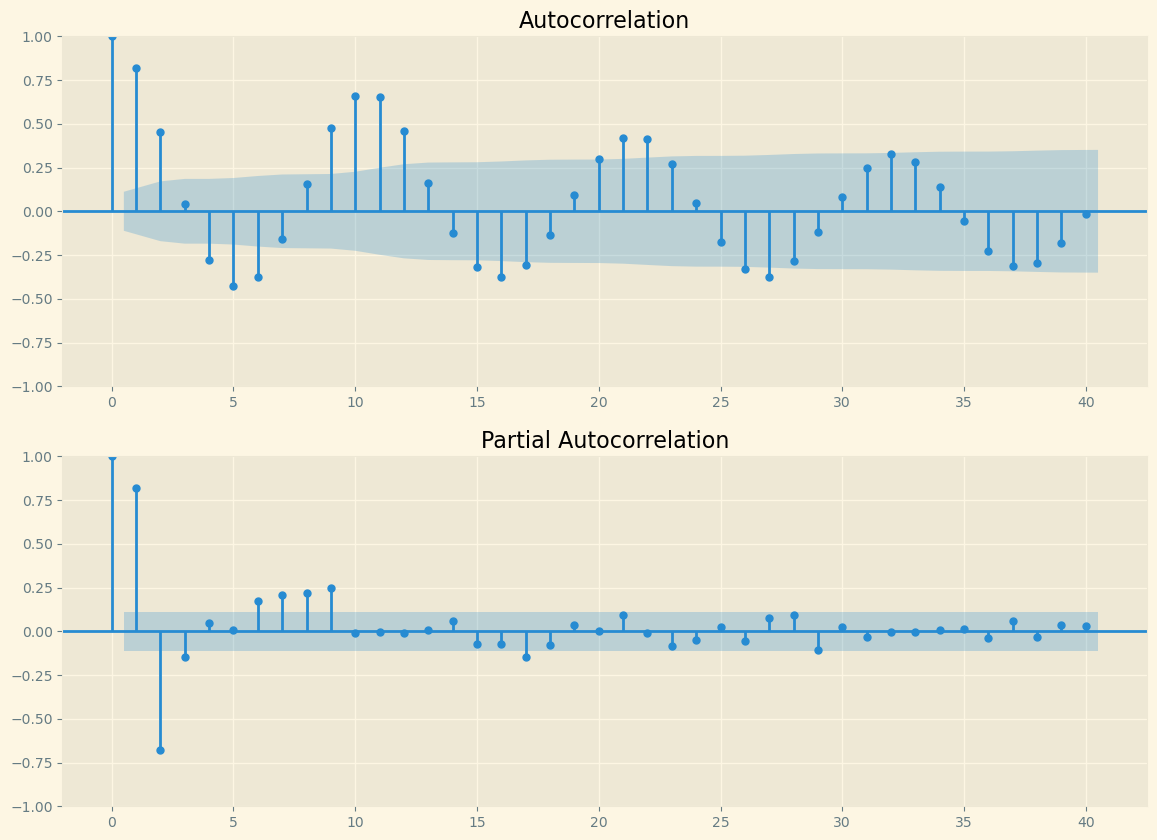

In [56]:
fig=plt.figure(figsize=(14,10))
ax1=fig.add_subplot(211)
fig=sm.graphics.tsa.plot_acf(dta.values.squeeze(), lags=40, ax=ax1)
ax2=fig.add_subplot(212)
fig=sm.graphics.tsa.plot_pacf(dta, lags=40, ax=ax2)

In [57]:
arma_mod20=ARIMA(dta, order=(2,0,0)).fit()
print(arma_mod20.params)

const      49.746198
ar.L1       1.390633
ar.L2      -0.688573
sigma2    274.727182
dtype: float64


In [58]:
arma_mod30=ARIMA(dta, order=(3,0,0)).fit()
print(arma_mod20.aic, arma_mod20.bic, arma_mod20.hqic)

2622.6370933011694 2637.5704584087603 2628.6074811464155


In [59]:
print(arma_mod30.params)

const      49.751911
ar.L1       1.300818
ar.L2      -0.508102
ar.L3      -0.129644
sigma2    270.101140
dtype: float64


In [60]:
print(arma_mod30.aic, arma_mod30.bic, arma_mod30.hqic)

2619.4036292456476 2638.0703356301365 2626.866614052205


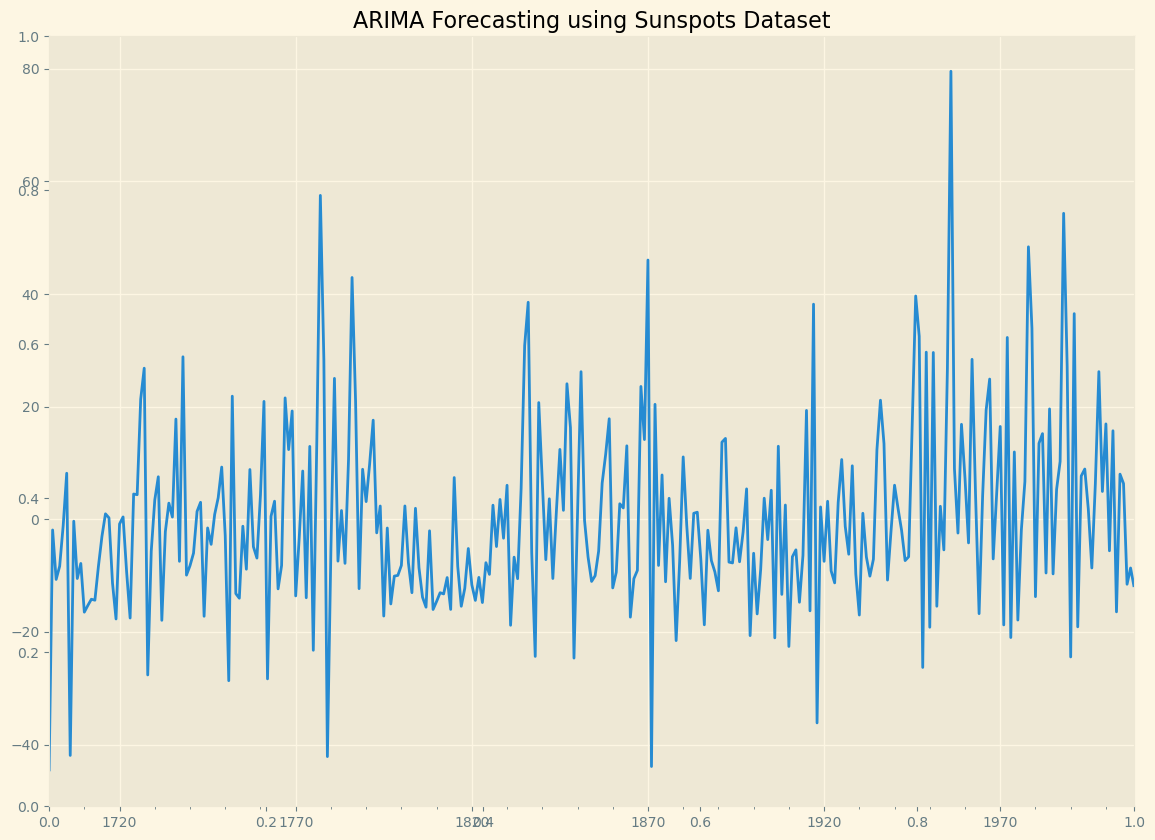

In [61]:
fig=plt.figure(figsize=(14,10))
plt.title("ARIMA Forecasting using Sunspots Dataset")
ax=fig.add_subplot(111)
ax=arma_mod30.resid.plot(ax=ax)

In [62]:
resid=arma_mod30.resid

In [63]:
stats.normaltest(resid)

NormaltestResult(statistic=49.843932216707096, pvalue=1.5015079671899095e-11)

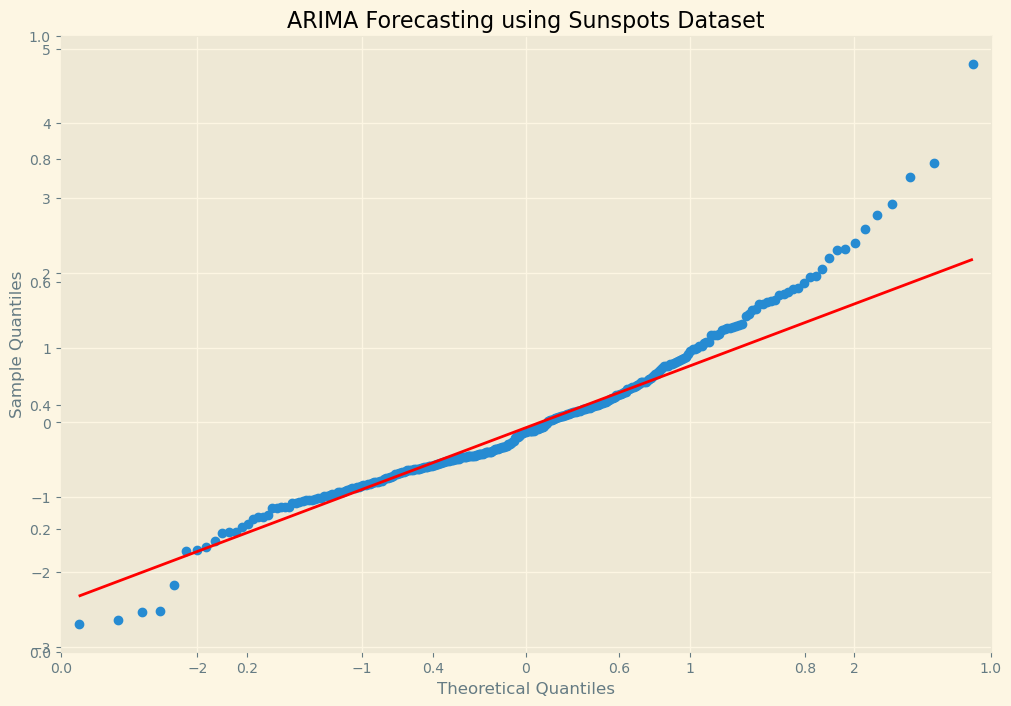

In [64]:
fig=plt.figure(figsize=(12,8))
plt.title("ARIMA Forecasting using Sunspots Dataset")
ax=fig.add_subplot(111)
fig=qqplot(resid, line="q", ax=ax, fit=True)

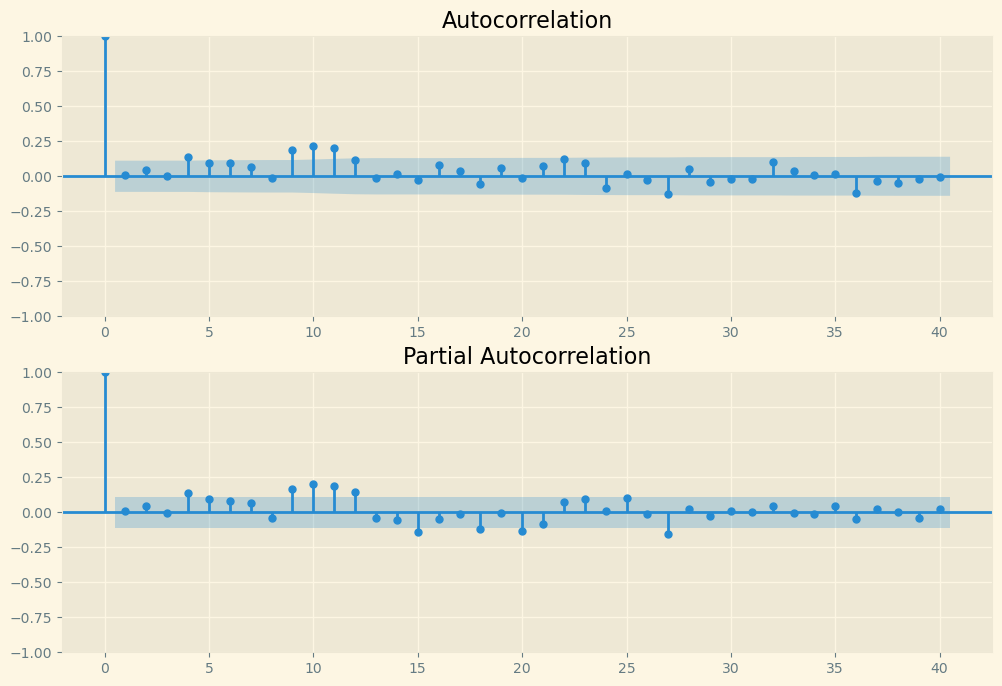

In [65]:
fig=plt.figure(figsize=(12,8))
ax1=fig.add_subplot(211)
fig=sm.graphics.tsa.plot_acf(resid.values.squeeze(), lags=40, ax=ax1)
ax2=fig.add_subplot(212)
fig=sm.graphics.tsa.plot_pacf(resid, lags=40, ax=ax2)

In [66]:
r, q, p=sm.tsa.acf(resid.values.squeeze(), fft=True, qstat=True)
data=np.c_[np.arange(1,25),r[1:],q,p]

In [67]:
table=pd.DataFrame(data, columns=["lag", "AC", "Q", "Prob(>Q)"])
print(table.set_index("lag"))
table.head(10)

            AC          Q      Prob(>Q)
lag                                    
1.0   0.009170   0.026239  8.713184e-01
2.0   0.041793   0.572982  7.508939e-01
3.0  -0.001338   0.573544  9.024612e-01
4.0   0.136086   6.408642  1.706385e-01
5.0   0.092465   9.111351  1.047043e-01
6.0   0.091947  11.792661  6.675737e-02
7.0   0.068747  13.296552  6.520425e-02
8.0  -0.015022  13.368601  9.978086e-02
9.0   0.187590  24.641072  3.394963e-03
10.0  0.213715  39.320758  2.230588e-05
11.0  0.201079  52.359565  2.346490e-07
12.0  0.117180  56.802479  8.580351e-08
13.0 -0.014057  56.866630  1.895209e-07
14.0  0.015398  56.943864  4.000370e-07
15.0 -0.024969  57.147642  7.746546e-07
16.0  0.080916  59.295052  6.876728e-07
17.0  0.041138  59.852008  1.111674e-06
18.0 -0.052022  60.745723  1.549418e-06
19.0  0.062496  62.040010  1.832778e-06
20.0 -0.010303  62.075305  3.383285e-06
21.0  0.074453  63.924941  3.195540e-06
22.0  0.124954  69.152954  8.984238e-07
23.0  0.093162  72.069214  5.803579e-07


,lag,AC,Q,Prob(>Q)
0,1.0,0.009170,0.026239,0.871318
1,2.0,0.041793,0.572982,0.750894
2,3.0,-0.001338,0.573544,0.902461
3,4.0,0.136086,6.408642,0.170638
4,5.0,0.092465,9.111351,0.104704
5,6.0,0.091947,11.792661,0.066757
6,7.0,0.068747,13.296552,0.065204
7,8.0,-0.015022,13.368601,0.099781
8,9.0,0.187590,24.641072,0.003395
9,10.0,0.213715,39.320758,0.000022


In [68]:
predict_sunspots=arma_mod30.predict("1990", "2012", dymanic=True)
print(predict_sunspots)

1990-12-31    167.048337
1991-12-31    109.192189
1992-12-31    113.404695
1993-12-31     46.912199
1994-12-31     20.984301
1995-12-31     15.689471
1996-12-31     17.256329
1997-12-31     15.181728
1998-12-31     38.091976
1999-12-31     88.366291
2000-12-31    102.670815
2001-12-31    116.598588
2002-12-31     88.288783
2003-12-31     80.143101
2004-12-31     32.391797
2005-12-31     23.466779
2006-12-31     26.741552
2007-12-31     16.156203
2008-12-31     14.932428
2009-12-31     14.753858
2010-12-31     33.509098
2011-12-31     52.479638
2012-12-31     66.090489
Freq: A-DEC, Name: predicted_mean, dtype: float64


In [69]:
def mean_forecast_err(y, yhat):
    return y.sub(yhat).mean()

In [70]:
mean_forecast_err(dta.SUNACTIVITY, predict_sunspots)

1.7306546428439595